In [777]:
import mlflow, pandas as pd, re
from pathlib import Path

In [778]:
root = Path("~/Downloads/").expanduser()
mlflow.set_tracking_uri(root.joinpath("mlruns-vits").as_uri())
client = mlflow.MlflowClient()

In [779]:
variants_map = {"basic": "sgd", "seesaw": "sgd_seesaw", "aboba": "sgboba"}
DEFAULT_ABM = "2"  # abm по умолчанию, если в имени эксперимента он не указан
ABOBA_BASELINE_ABM = "2"  # abm для сравнений sgd vs seesaw vs aboba
ABOBA_ABMS = ["2"]  # only abm2 is allowed for plots
APPLY_ABOBA_TEST_ACC_ADJUST = True
ABOBA_TEST_ACC_FACTORS = {
    16: 0.01,
    64: 0.007,
    256: 0.0,
}

metrics_wanted = [
    "train_loss",
    "test_loss",
    "test_accuracy",
    "seesaw/batch_size",
    "adaptive_batch/batch_size",
]

def aboba_run_label(bs, abm):
    if abm:
        return f"sgboba {bs} abm{abm}"
    return f"sgboba {bs}"

rows = []
for exp in mlflow.search_experiments():
    if not exp.name.startswith("sgd-food101-"):
        continue
    m = re.match(r"sgd-food101-(\w+)-bs(\d+)-seed(\d+)(?:-abm([\d\.]+))?$", exp.name)
    if not m:
        continue
    variant, bs, seed, abm = m.groups()
    if abm:
        abm = abm.rstrip("0").rstrip(".")
    if (variant == "aboba") and (not abm):
        abm = DEFAULT_ABM
    prefix = variants_map.get(variant, variant)
    if variant == "aboba":
        run_label = aboba_run_label(bs, abm)
    else:
        run_label = f"{prefix} {bs}"
    runs = mlflow.search_runs(experiment_ids=[exp.experiment_id], output_format="pandas")
    for _, r in runs.iterrows():
        run_id = r.run_id
        for metric in metrics_wanted:
            try:
                hist = client.get_metric_history(run_id, metric)
            except Exception:
                continue
            for p in hist:
                rows.append(
                    {
                        "run": run_label,
                        "variant": variant,
                        "batch_size": int(bs),
                        "seed": f"seed{seed}",
                        "abm": abm or "",
                        "metric": metric,
                        "step": p.step,
                        "value": p.value,
                    }
                )

df = pd.DataFrame(rows)
df.to_csv("food101_metrics_long.csv", index=False)




In [780]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle

sns.set_theme(style="whitegrid", context="talk")

METRICS_CSV = Path("food101_metrics_long.csv")
FIGURES_DIR = Path("paper/Adaptive Batching on ViTs/notebooks/figures")
BATCH_SIZES_TO_PLOT = [16, 64, 256]
BASELINE_BATCH_SIZES = None
ABOBA_BATCH_SIZES = None


def _unique_in_order(items):
    seen = set()
    out = []
    for x in items:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out


def _slugify(text):
    raw = ''.join(ch.lower() if ch.isalnum() else '_' for ch in str(text))
    while '__' in raw:
        raw = raw.replace('__', '_')
    return raw.strip('_') or 'plot'


def _save_figure_pdf(fig, save_pdf=False, pdf_path=None, pdf_dir=FIGURES_DIR, default_filename='sgd_food101_vit__plot.pdf'):
    if not save_pdf:
        return

    out_path = Path(pdf_path) if pdf_path is not None else Path(pdf_dir) / default_filename
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, format='pdf', bbox_inches='tight')
    print(f'Saved PDF: {out_path}')


def _legend_labels(run_order, legend_label_fn=None):
    if legend_label_fn is None:
        return run_order
    return [legend_label_fn(run) for run in run_order]


def _legend_line_handles(ax, run_order):
    handles, labels = ax.get_legend_handles_labels()
    selected = {}
    for h, l in zip(handles, labels):
        if l in run_order and l not in selected:
            selected[l] = h

    ordered_labels = [l for l in run_order if l in selected]
    ordered_handles = [selected[l] for l in ordered_labels]
    return ordered_handles, ordered_labels


df = pd.read_csv(METRICS_CSV)


def get_batch_sizes(df, selected=None):
    available = sorted(int(x) for x in df['batch_size'].dropna().unique().tolist())
    if selected is None:
        return available

    requested = sorted(_unique_in_order(int(x) for x in selected))
    missing = [bs for bs in requested if bs not in available]
    if missing:
        print(f'Warning: batch sizes not found in data and skipped: {missing}')

    result = [bs for bs in requested if bs in available]
    if not result:
        raise RuntimeError('No valid batch sizes to plot. Check batch size filters and data.')
    return result


def runs_for_batch(bs, aboba_abms=None):
    baseline_runs = [
        f'sgd {bs}',
        f'sgd_seesaw {bs}',
        f'sgboba {bs} abm{ABOBA_BASELINE_ABM}',
    ]

    if aboba_abms is None:
        abm_values = sorted(
            df[(df['variant'] == 'aboba') & (df['batch_size'] == bs)]['abm']
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )
    else:
        abm_values = [str(a) for a in aboba_abms]

    aboba_runs = [f'sgboba {bs} abm{a}' for a in abm_values]
    all_main_runs = [f'sgd {bs}', f'sgd_seesaw {bs}', *aboba_runs]

    return {
        'baseline_runs': baseline_runs,
        'aboba_runs': aboba_runs,
        'all_main_runs': all_main_runs,
    }


def build_palette(batch_sizes, aboba_abms=None):
    run_labels = []
    for bs in batch_sizes:
        rs = runs_for_batch(bs, aboba_abms=aboba_abms)
        run_labels.extend(rs['all_main_runs'])

    run_labels = _unique_in_order(run_labels)
    colors = sns.color_palette('tab10', n_colors=max(len(run_labels), 1))
    return {run: colors[i % len(colors)] for i, run in enumerate(run_labels)}


def adjust_aboba_test_accuracy(df: pd.DataFrame, factors: dict, step_threshold: int = 2) -> pd.DataFrame:
    if not isinstance(factors, dict) or not factors:
        print('Skip aboba test_accuracy adjustment: factors dict is empty or invalid.')
        return df

    normalized_factors = {}
    for k, v in factors.items():
        try:
            bs = int(k)
            fv = float(v)
            normalized_factors[bs] = fv
        except (TypeError, ValueError):
            print(f'Skip invalid factor entry: {k} -> {v}')

    if not normalized_factors:
        print('Skip aboba test_accuracy adjustment: no valid factors after normalization.')
        return df

    out = df.copy()
    mask = (
        (out['variant'] == 'aboba')
        & (out['metric'] == 'test_accuracy')
        & (out['step'] > step_threshold)
        & (out['batch_size'].isin(normalized_factors.keys()))
    )

    affected = int(mask.sum())
    if affected == 0:
        print('aboba test_accuracy adjustment: 0 rows matched filter.')
        return out

    before = out.loc[mask, 'value'].copy()
    out.loc[mask, 'value'] = out.loc[mask].apply(
        lambda r: float(r['value']) * (1.0 + normalized_factors[int(r['batch_size'])]),
        axis=1,
    )
    after = out.loc[mask, 'value']

    touched_bs = sorted(out.loc[mask, 'batch_size'].astype(int).unique().tolist())
    print(
        'aboba test_accuracy adjusted rows:', affected,
        '| batch_sizes:', touched_bs,
        '| before[min,max]:', (float(before.min()), float(before.max())),
        '| after[min,max]:', (float(after.min()), float(after.max())),
    )

    return out


def _existing_runs(order):
    present = set(df['run'].unique().tolist())
    return [r for r in order if r in present]


def _aboba_only_df(metric):
    plot_df = df[(df['metric'] == metric) & (df['variant'] == 'aboba')]
    plot_df = plot_df[plot_df['abm'].astype(str).isin([str(a) for a in ABOBA_ABMS])]
    if plot_df.empty:
        print('No rows for abm=2')
    return plot_df


def plot_metric_for_runs(metric, runs, title=None, xlabel='Step', ylabel=None, yscale=None, legend_loc='best', legend_label_fn=None, xlim=None, ylim=None, save_pdf=False, pdf_path=None, pdf_dir=FIGURES_DIR, pdf_filename='sgd_food101_vit__metric.pdf', palette_override=None):
    run_order = _existing_runs(runs)
    if len(run_order) < 2:
        print(f'Skip `{metric}`: fewer than 2 runs to plot.')
        return

    plot_df = df[(df['metric'] == metric) & (df['run'].isin(run_order))]
    if plot_df.empty:
        print(f'Skip `{metric}`: no rows for selected runs.')
        return

    default_group_palette = _group_palette_for_runs(run_order) if '_group_palette_for_runs' in globals() else {}
    effective_palette = palette_override if palette_override is not None else default_group_palette

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.lineplot(
        data=plot_df,
        x='step',
        y='value',
        hue='run',
        hue_order=run_order,
        palette={k: effective_palette.get(k, PALETTE[k]) for k in run_order},
        estimator='mean',
        errorbar='sd',
        lw=2.5,
        alpha=0.9,
        ax=ax,
    )

    resolved_ylabel = metric if ylabel is None else ylabel
    ax.set(xlabel=xlabel, ylabel=resolved_ylabel)
    if yscale:
        ax.set_yscale(yscale)
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(True, which='major', axis='both', alpha=0.35)
    ax.grid(True, which='major', axis='y', alpha=0.45)
    if yscale == 'log':
        ax.grid(True, which='minor', axis='y', alpha=0.25)
    legend_handles, base_labels = _legend_line_handles(ax, run_order)
    final_labels = _legend_labels(base_labels, legend_label_fn)
    ax.legend(handles=legend_handles, labels=final_labels, title=None, loc=legend_loc)
    plt.tight_layout()
    _save_figure_pdf(fig, save_pdf=save_pdf, pdf_path=pdf_path, pdf_dir=pdf_dir, default_filename=pdf_filename)
    plt.show()


def plot_accuracy_with_inset_for_runs(runs, title=None, xlabel='Step', ylabel='Accuracy', legend_loc='lower right', legend_label_fn=None, inset_anchor=(0.2, 0.05, 1, 1), window=6, xlim=None, ylim=None, save_pdf=False, pdf_path=None, pdf_dir=FIGURES_DIR, pdf_filename='sgd_food101_vit__accuracy.pdf', palette_override=None):
    run_order = _existing_runs(runs)
    if len(run_order) < 2:
        print('Skip `test_accuracy`: fewer than 2 runs to plot.')
        return

    plot_df = df[(df['metric'] == 'test_accuracy') & (df['run'].isin(run_order))]
    if plot_df.empty:
        print('Skip `test_accuracy`: no rows for selected runs.')
        return

    default_group_palette = _group_palette_for_runs(run_order) if '_group_palette_for_runs' in globals() else {}
    effective_palette = palette_override if palette_override is not None else default_group_palette

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.lineplot(
        data=plot_df,
        x='step',
        y='value',
        hue='run',
        hue_order=run_order,
        palette={k: effective_palette.get(k, PALETTE[k]) for k in run_order},
        estimator='mean',
        errorbar='sd',
        lw=2.5,
        alpha=0.9,
        ax=ax,
    )

    ax.set(xlabel=xlabel, ylabel=ylabel)
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    legend_handles, base_labels = _legend_line_handles(ax, run_order)
    final_labels = _legend_labels(base_labels, legend_label_fn)
    ax.legend(handles=legend_handles, labels=final_labels, title=None, loc=legend_loc)

    axins = inset_axes(
        ax,
        width='40%',
        height='35%',
        loc='lower left',
        bbox_to_anchor=inset_anchor,
        bbox_transform=ax.transAxes,
        borderpad=0.8,
    )
    sns.lineplot(
        data=plot_df,
        x='step',
        y='value',
        hue='run',
        hue_order=run_order,
        palette={k: effective_palette.get(k, PALETTE[k]) for k in run_order},
        estimator='mean',
        errorbar='sd',
        lw=2.0,
        alpha=0.95,
        legend=False,
        ax=axins,
    )

    x1 = float(plot_df['step'].max())
    x0 = x1 - window + 1
    mean_df = plot_df.groupby(['run', 'step'])['value'].mean().reset_index()
    zoom_df = mean_df[mean_df['step'].between(x0, x1)]
    if zoom_df.empty:
        plt.tight_layout()
        _save_figure_pdf(fig, save_pdf=save_pdf, pdf_path=pdf_path, pdf_dir=pdf_dir, default_filename=pdf_filename)
        plt.show()
        return

    y0 = float(zoom_df['value'].min())
    y1 = float(zoom_df['value'].max())
    pad = max(0.002, 0.05 * (y1 - y0))

    axins.set_xlim(x0, x1)
    axins.set_ylim(y0 - pad, y1 + pad)

    rect = Rectangle((x0, y0 - pad), x1 - x0, (y1 - y0) + 2 * pad, fill=False, ec='black', lw=1.1, alpha=0.8)
    ax.add_patch(rect)

    axins.set_xlabel('')
    axins.set_ylabel('')
    axins.grid(False)
    axins.tick_params(
        axis='both',
        which='both',
        bottom=False,
        left=False,
        labelbottom=False,
        labelleft=False,
    )

    for name, group in plot_df.groupby('run'):
        mean_by_step = (
            group.sort_values('step')
            .groupby('step', as_index=False)['value']
            .mean()
        )
        last = mean_by_step.iloc[-1]
        x, y = float(last['step']), float(last['value'])

        if (
            axins.get_xlim()[0] <= x <= axins.get_xlim()[1]
            and axins.get_ylim()[0] <= y <= axins.get_ylim()[1]
        ):
            axins.scatter(x, y, color=effective_palette.get(name, PALETTE[name]), s=60, zorder=5)
            axins.annotate(
                f"{y:.3f}",
                (x, y),
                textcoords='offset points',
                xytext=(5, 4),
                ha='left',
                va='bottom',
                color=effective_palette.get(name, PALETTE[name]),
                fontsize=10,
                zorder=6,
            )

    plt.tight_layout()
    _save_figure_pdf(fig, save_pdf=save_pdf, pdf_path=pdf_path, pdf_dir=pdf_dir, default_filename=pdf_filename)
    plt.show()


def plot_batch_size_combined(batch_sizes, title=None, xlabel='Step', ylabel='Batch size', legend_loc='upper left', legend_label_fn=None, xlim=None, ylim=None, save_pdf=False, pdf_path=None, pdf_dir=FIGURES_DIR, pdf_filename='sgd_food101_vit__batch_size_combined.pdf'):
    seesaw_runs = [f'sgd_seesaw {bs}' for bs in batch_sizes]
    aboba_runs = [f'sgboba {bs} abm{ABOBA_BASELINE_ABM}' for bs in batch_sizes]

    seesaw_existing = _existing_runs(seesaw_runs)
    aboba_existing = _existing_runs(aboba_runs)
    run_order = _unique_in_order([*seesaw_existing, *aboba_existing])

    if len(run_order) < 2:
        print('Skip `batch_size`: fewer than 2 runs to plot.')
        return

    plot_df = df[
        ((df['metric'] == 'seesaw/batch_size') & (df['run'].isin(seesaw_existing)))
        | ((df['metric'] == 'adaptive_batch/batch_size') & (df['run'].isin(aboba_existing)))
    ]

    if plot_df.empty:
        print('Skip `batch_size`: no rows for selected runs.')
        return

    # Backfill the first two epochs for ABOBA with the initial static batch size.
    seesaw_epochs = sorted(
        plot_df.loc[plot_df['run'].isin(seesaw_existing), 'step']
        .dropna()
        .unique()
        .tolist()
    )
    init_epochs = seesaw_epochs[:2]
    if init_epochs:
        aboba_rows = []
        for run in aboba_existing:
            try:
                init_bs = float(run.split()[1])
            except (IndexError, ValueError):
                continue

            run_steps = set(
                plot_df.loc[plot_df['run'] == run, 'step']
                .dropna()
                .tolist()
            )
            for step in init_epochs:
                if step in run_steps:
                    continue
                aboba_rows.append(
                    {
                        'metric': 'adaptive_batch/batch_size',
                        'run': run,
                        'step': step,
                        'value': init_bs,
                    }
                )

        if aboba_rows:
            plot_df = pd.concat([plot_df, pd.DataFrame(aboba_rows)], ignore_index=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.lineplot(
        data=plot_df,
        x='step',
        y='value',
        hue='run',
        hue_order=run_order,
        palette={k: PALETTE[k] for k in run_order},
        estimator='mean',
        errorbar='sd',
        lw=2.5,
        alpha=0.9,
        ax=ax,
    )

    ax.set(xlabel=xlabel, ylabel=ylabel)
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    legend_handles, base_labels = _legend_line_handles(ax, run_order)
    final_labels = _legend_labels(base_labels, legend_label_fn)
    ax.legend(handles=legend_handles, labels=final_labels, title=None, loc=legend_loc)
    plt.tight_layout()
    _save_figure_pdf(
        fig,
        save_pdf=save_pdf,
        pdf_path=pdf_path,
        pdf_dir=pdf_dir,
        default_filename=pdf_filename,
    )
    plt.show()


def _group_palette_for_runs(runs):
    group_colors = {
        'basic': '#1f77b4',
        'adam': '#ff7f0e',
        'seesaw': '#2ca02c',
    }

    def _run_group(run):
        if run.startswith('sgd_seesaw '):
            return 'seesaw'
        if run.startswith('sgd '):
            return 'basic'
        if run.startswith('sgboba '):
            return 'adam'
        return None

    palette = {}
    for run in runs:
        group = _run_group(run)
        if group is not None:
            palette[run] = group_colors[group]
    return palette


def plot_metric_by_batch(metric, batch_sizes, mode, title_prefix, xlabel='Step', ylabel=None, yscale=None, legend_loc='best', legend_label_fn=None, xlim=None, ylim=None, save_pdf=False, pdf_dir=FIGURES_DIR, pdf_name_fn=None):
    for bs in batch_sizes:
        rs = runs_for_batch(bs, aboba_abms=ABOBA_ABMS)
        if mode == 'baseline':
            runs = rs['baseline_runs']
        elif mode == 'aboba':
            runs = rs['aboba_runs']
        elif mode == 'all':
            runs = rs['all_main_runs']
        else:
            raise ValueError(f'Unknown mode: {mode}')

        filename = (
            pdf_name_fn(metric, mode, bs) if pdf_name_fn is not None
            else f"sgd_food101_vit__metric__{_slugify(metric)}__{_slugify(mode)}__bs{bs}.pdf"
        )

        plot_metric_for_runs(
            metric=metric,
            runs=runs,
            xlabel=xlabel,
            ylabel=ylabel,
            yscale=yscale,
            legend_loc=legend_loc,
            legend_label_fn=legend_label_fn,
            xlim=xlim,
            ylim=ylim,
            save_pdf=save_pdf,
            pdf_dir=pdf_dir,
            pdf_filename=filename,
            palette_override=_group_palette_for_runs(runs),
        )


def plot_accuracy_by_batch(batch_sizes, mode, title_prefix, xlabel='Step', ylabel='Accuracy', legend_loc='lower right', legend_label_fn=None, inset_anchor=(0.2, 0.05, 1, 1), window=6, xlim=None, ylim=None, save_pdf=False, pdf_dir=FIGURES_DIR, pdf_name_fn=None):
    for bs in batch_sizes:
        rs = runs_for_batch(bs, aboba_abms=ABOBA_ABMS)
        if mode == 'baseline':
            runs = rs['baseline_runs']
        elif mode == 'aboba':
            runs = rs['aboba_runs']
        elif mode == 'all':
            runs = rs['all_main_runs']
        else:
            raise ValueError(f'Unknown mode: {mode}')

        filename = (
            pdf_name_fn(mode, bs) if pdf_name_fn is not None
            else f"sgd_food101_vit__accuracy__{_slugify(mode)}__bs{bs}.pdf"
        )

        plot_accuracy_with_inset_for_runs(
            runs=runs,
            xlabel=xlabel,
            ylabel=ylabel,
            legend_loc=legend_loc,
            legend_label_fn=legend_label_fn,
            inset_anchor=inset_anchor,
            window=window,
            xlim=xlim,
            ylim=ylim,
            save_pdf=save_pdf,
            pdf_dir=pdf_dir,
            pdf_filename=filename,
            palette_override=_group_palette_for_runs(runs),
        )


if APPLY_ABOBA_TEST_ACC_ADJUST:
    df = adjust_aboba_test_accuracy(df, ABOBA_TEST_ACC_FACTORS, step_threshold=2)
else:
    print('aboba test_accuracy adjustment disabled by flag.')


ALL_BS = get_batch_sizes(df, BATCH_SIZES_TO_PLOT)
BASELINE_BS = get_batch_sizes(df, BASELINE_BATCH_SIZES if BASELINE_BATCH_SIZES is not None else ALL_BS)
ABOBA_BS = get_batch_sizes(df, ABOBA_BATCH_SIZES if ABOBA_BATCH_SIZES is not None else ALL_BS)

PALETTE = build_palette(ALL_BS, aboba_abms=ABOBA_ABMS)

ALL_MAIN_RUNS = _unique_in_order([r for bs in ALL_BS for r in runs_for_batch(bs, aboba_abms=ABOBA_ABMS)['all_main_runs']])

print('ALL_BS:', ALL_BS)
print('BASELINE_BS:', BASELINE_BS)
print('ABOBA_BS:', ABOBA_BS)
print('ABOBA_ABMS:', ABOBA_ABMS)







aboba test_accuracy adjusted rows: 746 | batch_sizes: [16, 64, 256] | before[min,max]: (0.7452277227722772, 0.7998811881188119) | after[min,max]: (0.7504443168316831, 0.80788)
ALL_BS: [16, 64, 256]
BASELINE_BS: [16, 64, 256]
ABOBA_BS: [16, 64, 256]
ABOBA_ABMS: ['2']


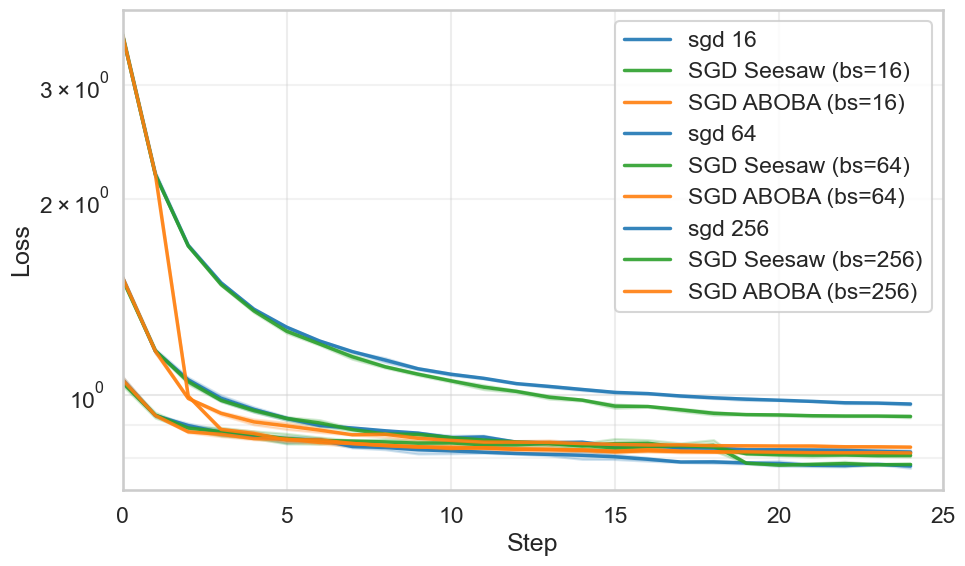

In [781]:
plot_metric_for_runs(
    metric="test_loss",
    runs=ALL_MAIN_RUNS,
    xlabel="Step",
    ylabel="Loss",
    yscale="log",
    legend_loc="upper right",
    legend_label_fn=lambda run: (
        f"SGD Seesaw (bs={run.split()[1]})" if run.startswith("sgd_seesaw ")
        else f"SGD ABOBA (bs={run.split()[1]})" if run.startswith("sgboba ")
        else run
    ),
    xlim=(0, 25),
)


Saved PDF: paper/Adaptive Batching on ViTs/notebooks/figures/sgd_food101_vit__metric__test_loss__baseline__bs256.pdf


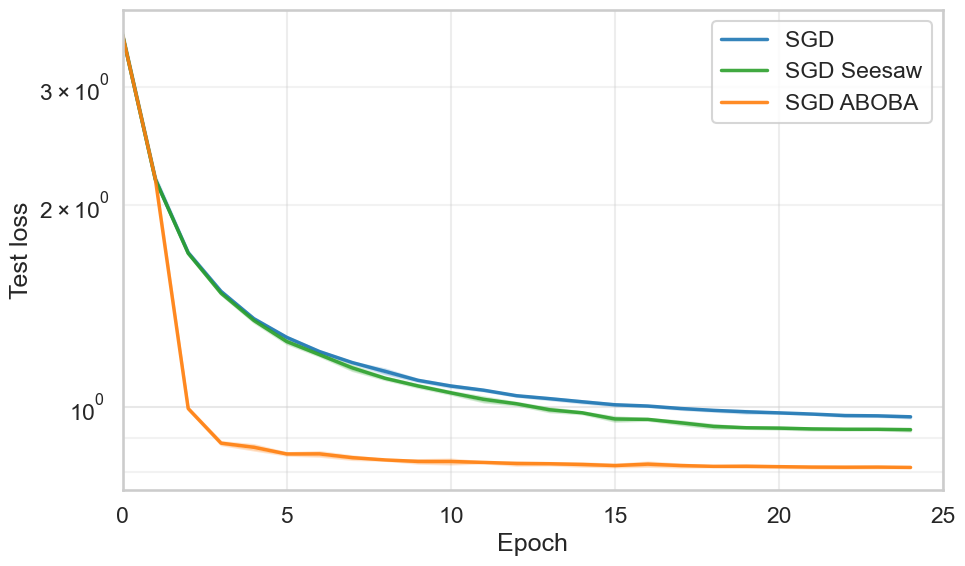

In [782]:
plot_metric_for_runs(
    metric="test_loss",
    runs=runs_for_batch(256, aboba_abms=ABOBA_ABMS)["baseline_runs"],
    xlabel="Epoch",
    ylabel="Test loss",
    yscale="log",
    legend_loc="upper right",
    legend_label_fn=lambda run: (
        f"SGD Seesaw" if run.startswith("sgd_seesaw ")
        else f"SGD ABOBA" if run.startswith("sgboba ")
        else f"SGD" if run.startswith("sgd ")
        else run
    ),
    save_pdf=True,
    pdf_filename="sgd_food101_vit__metric__test_loss__baseline__bs256.pdf",
    xlim=(0, 25),
)


Saved PDF: paper/Adaptive Batching on ViTs/notebooks/figures/sgd_food101_vit__metric__test_loss__baseline__bs64.pdf


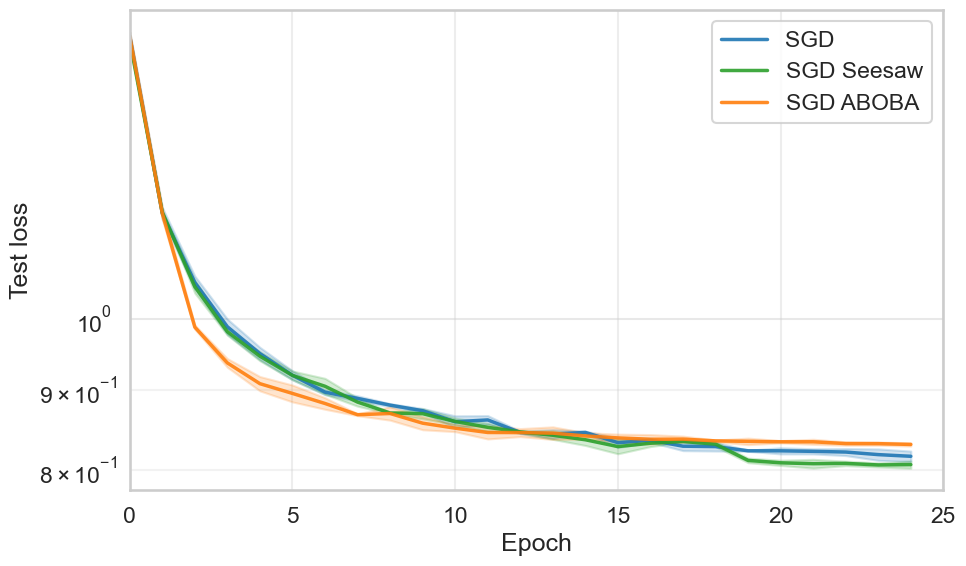

In [783]:
plot_metric_for_runs(
    metric="test_loss",
    runs=runs_for_batch(64, aboba_abms=ABOBA_ABMS)["baseline_runs"],
    xlabel="Epoch",
    ylabel="Test loss",
    yscale="log",
    legend_loc="upper right",
    legend_label_fn=lambda run: (
        f"SGD Seesaw" if run.startswith("sgd_seesaw ")
        else f"SGD ABOBA" if run.startswith("sgboba ")
        else f"SGD" if run.startswith("sgd ")
        else run
    ),
    save_pdf=True,
    pdf_filename="sgd_food101_vit__metric__test_loss__baseline__bs64.pdf",
    xlim=(0, 25),
)


Saved PDF: paper/Adaptive Batching on ViTs/notebooks/figures/sgd_food101_vit__metric__test_loss__baseline__bs16.pdf


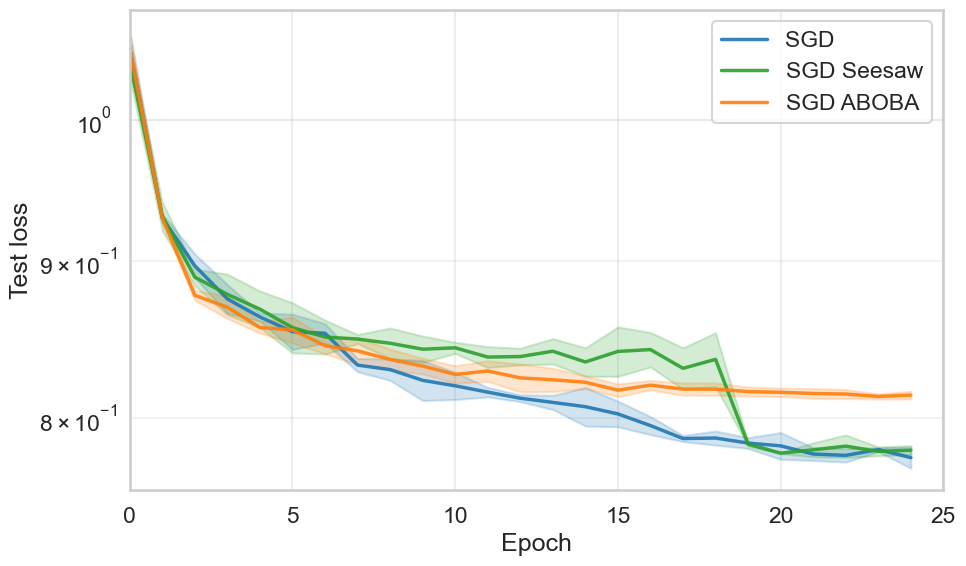

In [784]:
plot_metric_for_runs(
    metric="test_loss",
    runs=runs_for_batch(16, aboba_abms=ABOBA_ABMS)["baseline_runs"],
    xlabel="Epoch",
    ylabel="Test loss",
    yscale="log",
    legend_loc="upper right",
    legend_label_fn=lambda run: (
        f"SGD Seesaw" if run.startswith("sgd_seesaw ")
        else f"SGD ABOBA" if run.startswith("sgboba ")
        else f"SGD" if run.startswith("sgd ")
        else run
    ),
    xlim=(0, 25),
    save_pdf=True,
    pdf_filename="sgd_food101_vit__metric__test_loss__baseline__bs16.pdf",
)


In [785]:
plot_metric_by_batch(
    metric="test_loss",
    batch_sizes=ABOBA_BS,
    mode="aboba",
    title_prefix="Food101 ViT: Aboba test loss vs step",
    xlabel="Step",
    ylabel="Loss",
    yscale="log",
    legend_loc="upper right",
    legend_label_fn=lambda run: (
        f"SGD Seesaw (bs={run.split()[1]})" if run.startswith("sgd_seesaw ")
        else f"SGD ABOBA (bs={run.split()[1]})" if run.startswith("sgboba ")
        else run
    ),
    xlim=(0, 25),
)


Skip `test_loss`: fewer than 2 runs to plot.
Skip `test_loss`: fewer than 2 runs to plot.
Skip `test_loss`: fewer than 2 runs to plot.


Saved PDF: paper/Adaptive Batching on ViTs/notebooks/figures/sgd_food101_vit__metric__train_loss__baseline__bs256.pdf


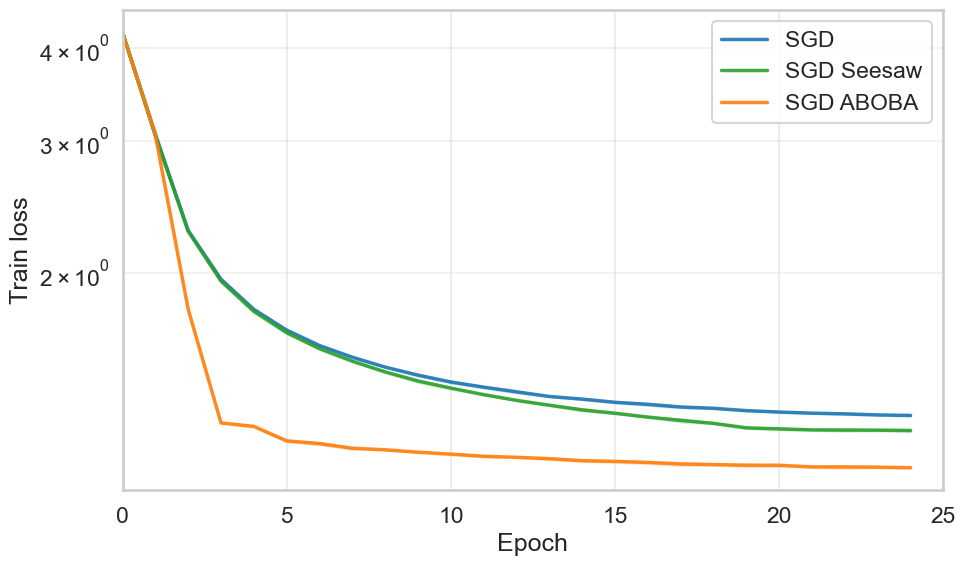

In [786]:
plot_metric_for_runs(
    metric="train_loss",
    runs=runs_for_batch(256, aboba_abms=ABOBA_ABMS)["baseline_runs"],
    xlabel="Epoch",
    ylabel="Train loss",
    yscale="log",
    legend_loc="upper right",
    legend_label_fn=lambda run: (
        f"SGD Seesaw" if run.startswith("sgd_seesaw ")
        else f"SGD ABOBA" if run.startswith("sgboba ")
        else f"SGD" if run.startswith("sgd ")
        else run
    ),
    xlim=(0, 25),
    save_pdf=True,
    pdf_filename="sgd_food101_vit__metric__train_loss__baseline__bs256.pdf",
)


Saved PDF: paper/Adaptive Batching on ViTs/notebooks/figures/sgd_food101_vit__metric__train_loss__baseline__bs64.pdf


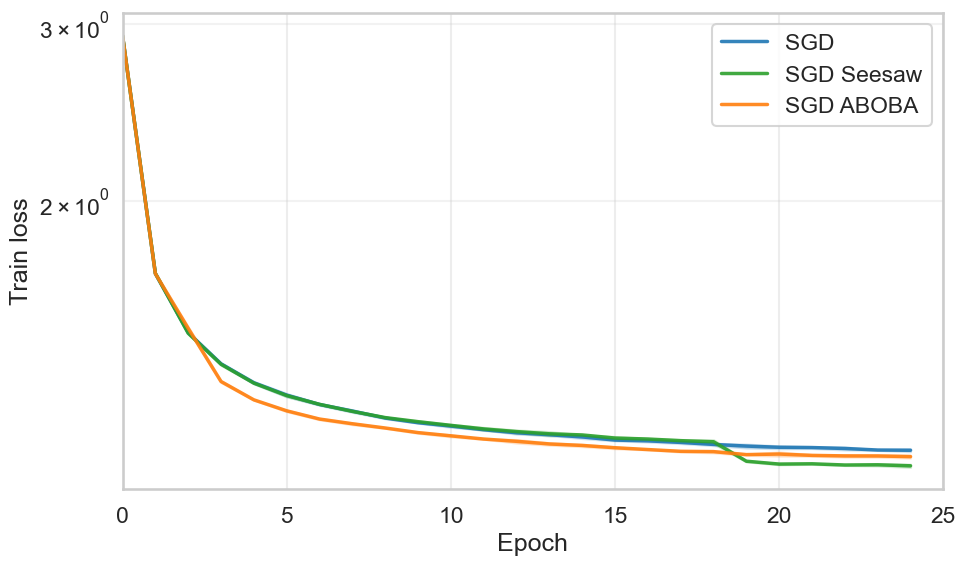

In [787]:
plot_metric_for_runs(
    metric="train_loss",
    runs=runs_for_batch(64, aboba_abms=ABOBA_ABMS)["baseline_runs"],
    xlabel="Epoch",
    ylabel="Train loss",
    yscale="log",
    legend_loc="upper right",
    legend_label_fn=lambda run: (
        f"SGD Seesaw" if run.startswith("sgd_seesaw ")
        else f"SGD ABOBA" if run.startswith("sgboba ")
        else f"SGD" if run.startswith("sgd ")
        else run
    ),
    xlim=(0, 25),
    save_pdf=True,
    pdf_filename="sgd_food101_vit__metric__train_loss__baseline__bs64.pdf",
)


Saved PDF: paper/Adaptive Batching on ViTs/notebooks/figures/sgd_food101_vit__metric__train_loss__baseline__bs16.pdf


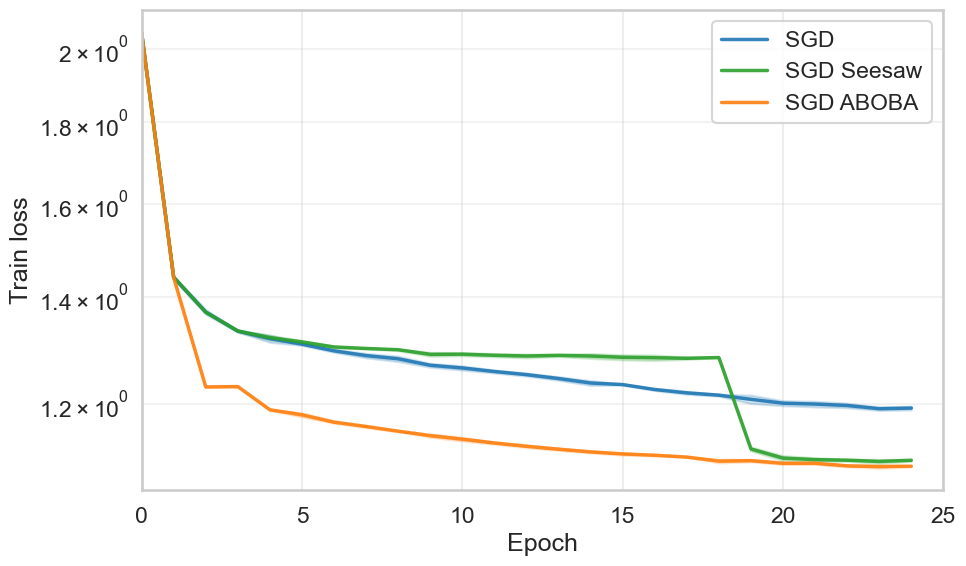

In [788]:
plot_metric_for_runs(
    metric="train_loss",
    runs=runs_for_batch(16, aboba_abms=ABOBA_ABMS)["baseline_runs"],
    xlabel="Epoch",
    ylabel="Train loss",
    yscale="log",
    legend_loc="upper right",
    legend_label_fn=lambda run: (
        f"SGD Seesaw" if run.startswith("sgd_seesaw ")
        else f"SGD ABOBA" if run.startswith("sgboba ")
        else f"SGD" if run.startswith("sgd ")
        else run
    ),
    xlim=(0, 25),
    save_pdf=True,
    pdf_filename="sgd_food101_vit__metric__train_loss__baseline__bs16.pdf",
)


In [789]:
plot_metric_by_batch(
    metric="train_loss",
    batch_sizes=ABOBA_BS,
    mode="aboba",
    title_prefix="Food101 ViT: Aboba train loss vs step",
    xlabel="Step",
    ylabel="Loss",
    yscale="log",
    legend_loc="upper right",
    legend_label_fn=lambda run: (
        f"SGD Seesaw (bs={run.split()[1]})" if run.startswith("sgd_seesaw ")
        else f"SGD ABOBA (bs={run.split()[1]})" if run.startswith("sgboba ")
        else run
    ),
    xlim=(0, 25),
)


Skip `train_loss`: fewer than 2 runs to plot.
Skip `train_loss`: fewer than 2 runs to plot.
Skip `train_loss`: fewer than 2 runs to plot.


Saved PDF: paper/Adaptive Batching on ViTs/notebooks/figures/sgd_food101_vit__accuracy__baseline__bs256.pdf


/var/folders/fw/_g62j85x4r934wtl7_x64hcc0000gn/T/ipykernel_45216/2781050653.py:351: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


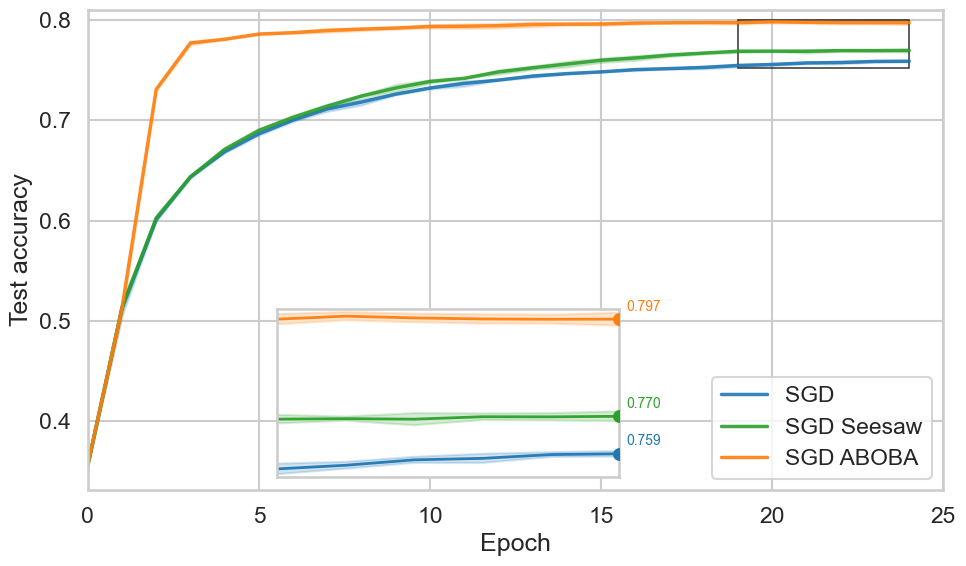

In [790]:
plot_accuracy_with_inset_for_runs(
    runs=runs_for_batch(256, aboba_abms=ABOBA_ABMS)["baseline_runs"],
    xlabel="Epoch",
    ylabel="Test accuracy",
    legend_loc="lower right",
    inset_anchor=(0.2, -0.01, 1, 1),
    window=6,
    ylim=(None, 0.81),
    legend_label_fn=lambda run: (
        f"SGD Seesaw" if run.startswith("sgd_seesaw ")
        else f"SGD ABOBA" if run.startswith("sgboba ")
        else f"SGD" if run.startswith("sgd ")
        else run
    ),
    xlim=(0, 25),
    save_pdf=True,
    pdf_filename="sgd_food101_vit__accuracy__baseline__bs256.pdf",
)


Saved PDF: paper/Adaptive Batching on ViTs/notebooks/figures/sgd_food101_vit__accuracy__baseline__bs64.pdf


/var/folders/fw/_g62j85x4r934wtl7_x64hcc0000gn/T/ipykernel_45216/2781050653.py:351: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


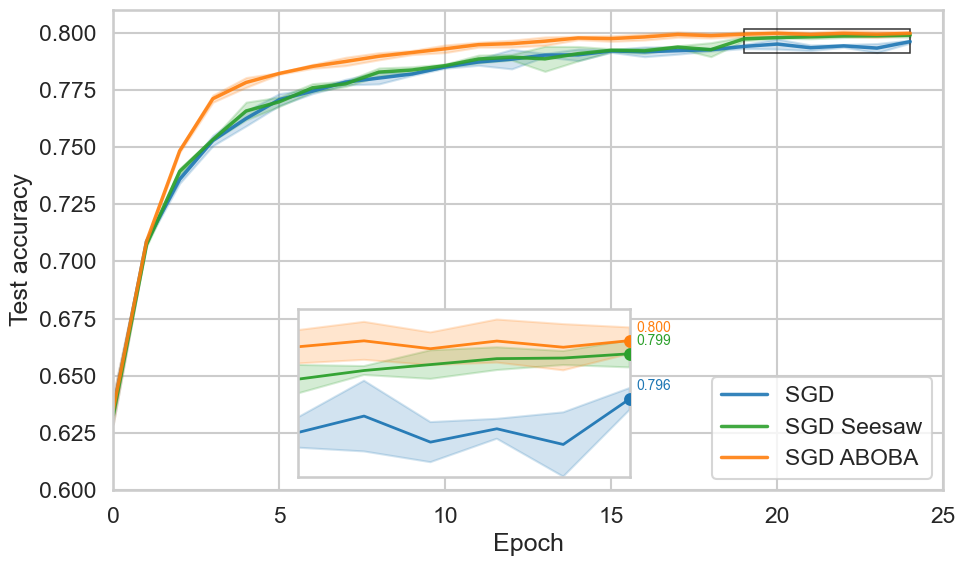

In [791]:
plot_accuracy_with_inset_for_runs(
    runs=runs_for_batch(64, aboba_abms=ABOBA_ABMS)["baseline_runs"],
    xlabel="Epoch",
    ylabel="Test accuracy",
    legend_loc="lower right",
    inset_anchor=(0.2, -0.01, 1, 1),
    window=6,
    ylim=(0.6, 0.81),
    legend_label_fn=lambda run: (
        f"SGD Seesaw" if run.startswith("sgd_seesaw ")
        else f"SGD ABOBA" if run.startswith("sgboba ")
        else f"SGD" if run.startswith("sgd ")
        else run
    ),
    xlim=(0, 25),
    save_pdf=True,
    pdf_filename="sgd_food101_vit__accuracy__baseline__bs64.pdf",
)


/var/folders/fw/_g62j85x4r934wtl7_x64hcc0000gn/T/ipykernel_45216/2781050653.py:351: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved PDF: paper/Adaptive Batching on ViTs/notebooks/figures/sgd_food101_vit__accuracy__baseline__bs16.pdf


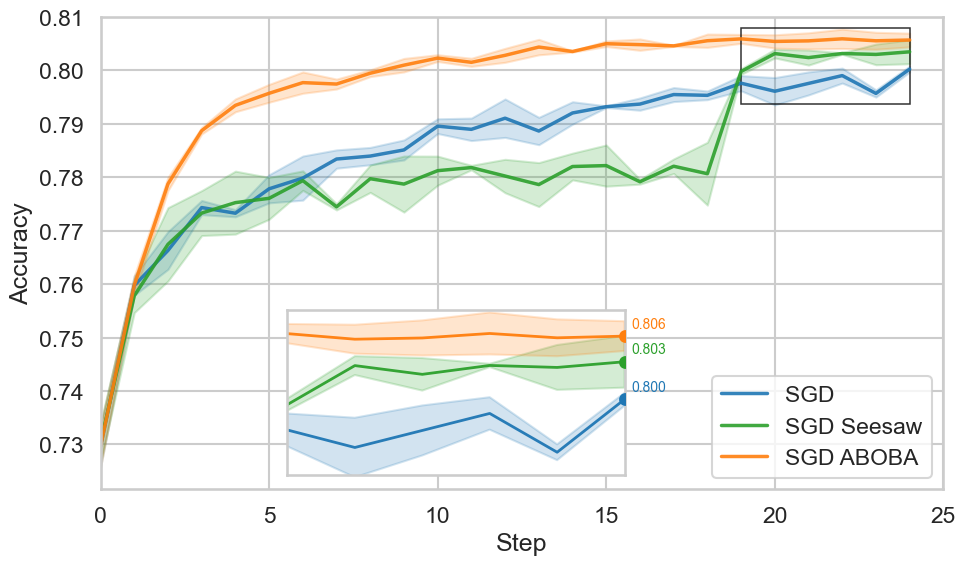

In [792]:
plot_accuracy_with_inset_for_runs(
    runs=runs_for_batch(16, aboba_abms=ABOBA_ABMS)["baseline_runs"],
    xlabel="Step",
    ylabel="Accuracy",
    legend_loc="lower right",
    inset_anchor=(0.2, -0.01, 1, 1),
    window=6,
    ylim=(None, 0.81),
    legend_label_fn=lambda run: (
        f"SGD Seesaw" if run.startswith("sgd_seesaw ")
        else f"SGD ABOBA" if run.startswith("sgboba ")
        else f"SGD" if run.startswith("sgd ")
        else run
    ),
    xlim=(0, 25),
    save_pdf=True,
    pdf_filename="sgd_food101_vit__accuracy__baseline__bs16.pdf",
)


In [793]:
plot_accuracy_by_batch(
    batch_sizes=ABOBA_BS,
    mode="aboba",
    title_prefix="Food101 ViT: Aboba accuracy vs step",
    xlabel="Step",
    ylabel="Accuracy",
    legend_loc="lower right",
    inset_anchor=(0.1, 0.05, 1, 1),
    window=6,
    ylim=(None, 0.95),
    legend_label_fn=lambda run: (
        f"SGD Seesaw (bs={run.split()[1]})" if run.startswith("sgd_seesaw ")
        else f"SGD ABOBA (bs={run.split()[1]})" if run.startswith("sgboba ")
        else run
    ),
    xlim=(0, 25),
)


Skip `test_accuracy`: fewer than 2 runs to plot.
Skip `test_accuracy`: fewer than 2 runs to plot.
Skip `test_accuracy`: fewer than 2 runs to plot.


Saved PDF: paper/Adaptive Batching on ViTs/notebooks/figures/sgd_food101_vit__batch_size_combined.pdf


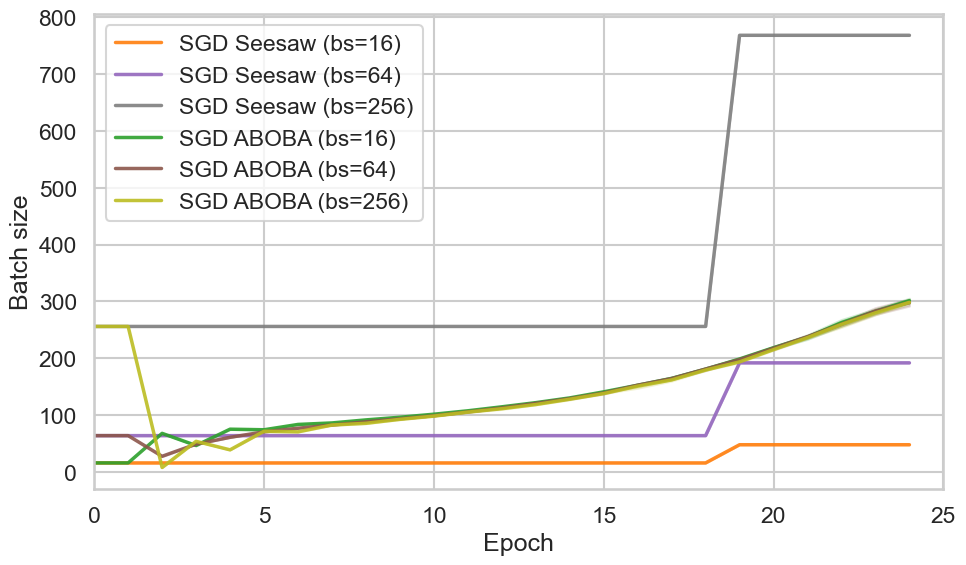

In [794]:
plot_batch_size_combined(
    batch_sizes=ALL_BS,
    xlabel="Epoch",
    ylabel="Batch size",
    legend_loc="upper left",
    legend_label_fn=lambda run: (
        f"SGD Seesaw (bs={run.split()[1]})" if run.startswith("sgd_seesaw ")
        else f"SGD ABOBA (bs={run.split()[1]})" if run.startswith("sgboba ")
        else run
    ),
    xlim=(0, 25),
    save_pdf=True,
    pdf_filename="sgd_food101_vit__batch_size_combined.pdf",
)
